# VGG — CIFAR-10

Dikonversi dari `03_vgg_cifar10.py`. Jalankan sel secara berurutan dengan kernel Python yang memiliki `torch` dan `torchvision`. Sel terakhir memulai pelatihan.

Dataset diunduh otomatis ke `./data`, relatif terhadap direktori kerja kernel.


## Import dan konfigurasi


In [ ]:
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
BATCH_SIZE = 64
EPOCHS = 50
TRAIN_SAMPLES = 5000
VAL_SAMPLES = 1000

## Seed untuk reproduksibilitas


In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Dataset dan DataLoader


In [ ]:
def get_dataloaders():
    transform_train = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    transform_test = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    train_set = datasets.CIFAR10("./data", train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

    g = torch.Generator().manual_seed(SEED)
    train_idx = torch.randperm(len(train_set), generator=g)[:TRAIN_SAMPLES]
    val_idx = torch.randperm(len(val_set), generator=g)[:VAL_SAMPLES]

    train_loader = DataLoader(
        Subset(train_set, train_idx),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        Subset(val_set, val_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    return train_loader, val_loader, len(train_set.classes)



## Fungsi pelatihan dan evaluasi


In [ ]:
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def run_training(model, model_name):
    set_seed()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader, num_classes = get_dataloaders()

    model = model(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print(f"Model: {model_name}")
    print("Dataset: CIFAR-10")
    print(f"Device: {device}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return model, history, val_loader, device


## Arsitektur model


In [19]:
class VGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        cfg = [32, 32, "M", 64, 64, "M", 128, 128, "M"]
        layers = []
        in_channels = 3

        for item in cfg:
            if item == "M":
                layers.append(nn.MaxPool2d(2))
            else:
                layers.extend([
                    nn.Conv2d(in_channels, item, 3, padding=1),
                    nn.BatchNorm2d(item),
                    nn.ReLU(inplace=True)
                ])
                in_channels = item

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)



## Jalankan pelatihan


In [20]:
trained_model, history, val_loader, device = run_training(VGG, "VGG")

Model: VGG
Dataset: CIFAR-10
Device: cuda
Parameters: 421,802
Epoch 01/50 | train_loss=1.8713 | train_acc=0.3034 | val_loss=1.7719 | val_acc=0.3410
Epoch 02/50 | train_loss=1.6395 | train_acc=0.3838 | val_loss=1.5978 | val_acc=0.4020
Epoch 03/50 | train_loss=1.4684 | train_acc=0.4572 | val_loss=1.8253 | val_acc=0.3800
Epoch 04/50 | train_loss=1.3912 | train_acc=0.4888 | val_loss=1.4597 | val_acc=0.4870
Epoch 05/50 | train_loss=1.3038 | train_acc=0.5246 | val_loss=1.4156 | val_acc=0.5140
Epoch 06/50 | train_loss=1.2283 | train_acc=0.5558 | val_loss=1.2176 | val_acc=0.5370
Epoch 07/50 | train_loss=1.1755 | train_acc=0.5712 | val_loss=1.2946 | val_acc=0.5490
Epoch 08/50 | train_loss=1.0965 | train_acc=0.6008 | val_loss=1.4627 | val_acc=0.4860
Epoch 09/50 | train_loss=1.0540 | train_acc=0.6224 | val_loss=1.1887 | val_acc=0.5640
Epoch 10/50 | train_loss=0.9960 | train_acc=0.6480 | val_loss=1.1735 | val_acc=0.5930
Epoch 11/50 | train_loss=1.0116 | train_acc=0.6418 | val_loss=1.1255 | val_acc

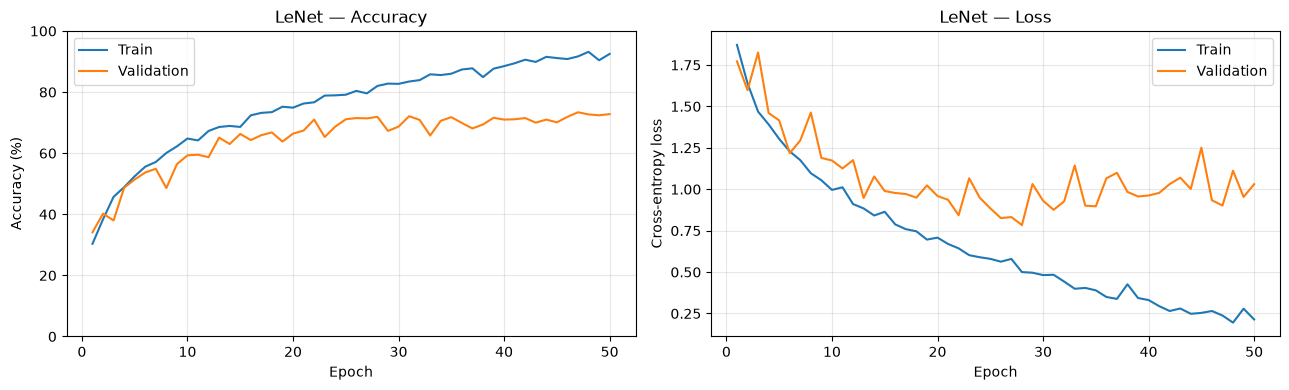

In [21]:
import matplotlib.pyplot as plt

if "history" not in globals() or not history["train_loss"]:
    raise RuntimeError("Jalankan ulang sel fungsi pelatihan dan sel pelatihan terlebih dahulu.")

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, [acc * 100 for acc in history["train_acc"]], label="Train")
axes[0].plot(epochs, [acc * 100 for acc in history["val_acc"]], label="Validation")
axes[0].set_title("LeNet — Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)

axes[1].plot(epochs, history["train_loss"], label="Train")
axes[1].plot(epochs, history["val_loss"], label="Validation")
axes[1].set_title("LeNet — Loss")
axes[1].set_ylabel("Cross-entropy loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


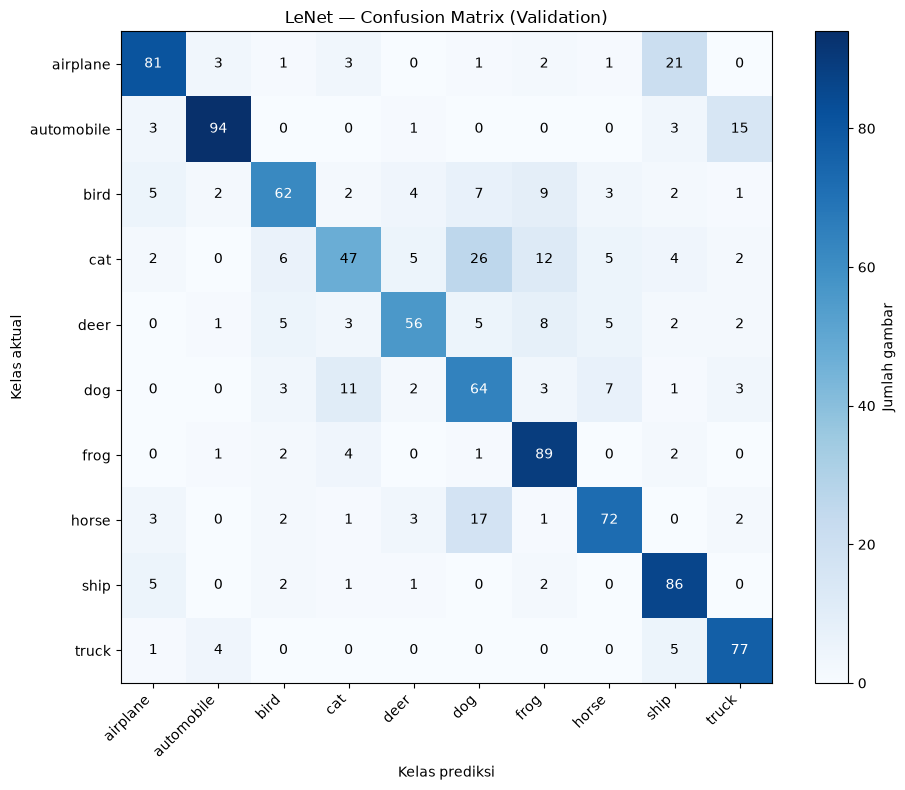

In [22]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for images, labels in loader:
        predictions = model(images.to(device)).argmax(dim=1).cpu()
        indices = labels.cpu() * num_classes + predictions
        matrix += torch.bincount(indices, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return matrix

if any(name not in globals() for name in ("trained_model", "val_loader", "device")):
    raise RuntimeError("Jalankan ulang sel fungsi pelatihan dan sel pelatihan terlebih dahulu.")

class_names = val_loader.dataset.dataset.classes
num_classes = len(class_names)
confusion_matrix = get_confusion_matrix(trained_model, val_loader, device, num_classes)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(confusion_matrix.numpy(), cmap="Blues", interpolation="nearest")
fig.colorbar(image, ax=ax, label="Jumlah gambar")
ax.set_xticks(range(num_classes), labels=class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes), labels=class_names)
ax.set_xlabel("Kelas prediksi")
ax.set_ylabel("Kelas aktual")
ax.set_title("LeNet — Confusion Matrix (Validation)")

threshold = confusion_matrix.max().item() / 2
for row in range(num_classes):
    for col in range(num_classes):
        count = confusion_matrix[row, col].item()
        ax.text(col, row, str(count), ha="center", va="center",
                color="white" if count > threshold else "black")

plt.tight_layout()
plt.show()
